In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load Datasets
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_set = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

# 3. DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

Using device: cpu


100%|██████████| 26.4M/26.4M [00:03<00:00, 8.55MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


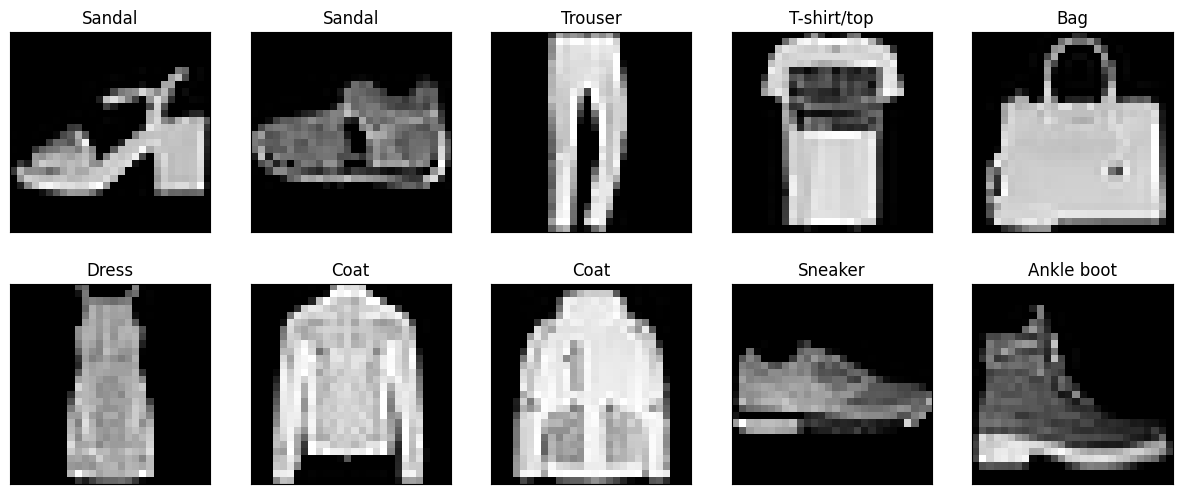

In [12]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(15, 6))

for i in np.arange(10):
    x = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])

    img = images[i].numpy() / 2 + 0.5
    x.imshow(np.squeeze(img), cmap='gray')
    x.set_title(classes[labels[i].item()])

plt.show()

In [8]:
model_1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_1.parameters(), lr=0.001)

In [10]:
epochs = 15
train_loss_1, val_loss_1 = [], []
train_acc_1, val_acc_1 = [], []

for epoch in range(epochs):
    model_1.train()
    running_loss = correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_1(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad();
        loss.backward();
        optimizer.step()

        running_loss += loss.item()
        total += labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss_1.append(running_loss / len(train_loader))
    train_acc_1.append(100 * correct / total)

    #Validation
    model_1.eval()
    val_running_loss = val_correct = val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_1(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            val_total += labels.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss_1.append(val_running_loss / len(test_loader))
    val_acc_1.append(100 * val_correct / val_total)

    # طباعة النتائج لكل Epoch
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_1[-1]:.4f}, Train Acc: {train_acc_1[-1]:.2f}% | Val Loss: {val_loss_1[-1]:.4f}, Val Acc: {val_acc_1[-1]:.2f}%")

Epoch [1/15] | Train Loss: 1.3833, Train Acc: 63.78% | Val Loss: 1.0911, Val Acc: 68.26%
Epoch [2/15] | Train Loss: 0.9505, Train Acc: 71.53% | Val Loss: 0.8633, Val Acc: 71.54%
Epoch [3/15] | Train Loss: 0.7979, Train Acc: 73.82% | Val Loss: 0.7675, Val Acc: 73.99%
Epoch [4/15] | Train Loss: 0.7243, Train Acc: 75.23% | Val Loss: 0.7163, Val Acc: 75.28%
Epoch [5/15] | Train Loss: 0.6785, Train Acc: 76.59% | Val Loss: 0.6790, Val Acc: 76.04%
Epoch [6/15] | Train Loss: 0.6444, Train Acc: 77.64% | Val Loss: 0.6499, Val Acc: 77.15%
Epoch [7/15] | Train Loss: 0.6167, Train Acc: 78.51% | Val Loss: 0.6231, Val Acc: 78.01%
Epoch [8/15] | Train Loss: 0.5936, Train Acc: 79.27% | Val Loss: 0.6033, Val Acc: 78.48%
Epoch [9/15] | Train Loss: 0.5740, Train Acc: 79.97% | Val Loss: 0.5836, Val Acc: 79.37%
Epoch [10/15] | Train Loss: 0.5561, Train Acc: 80.52% | Val Loss: 0.5698, Val Acc: 79.97%
Epoch [11/15] | Train Loss: 0.5407, Train Acc: 81.10% | Val Loss: 0.5564, Val Acc: 80.34%
Epoch [12/15] | Tra

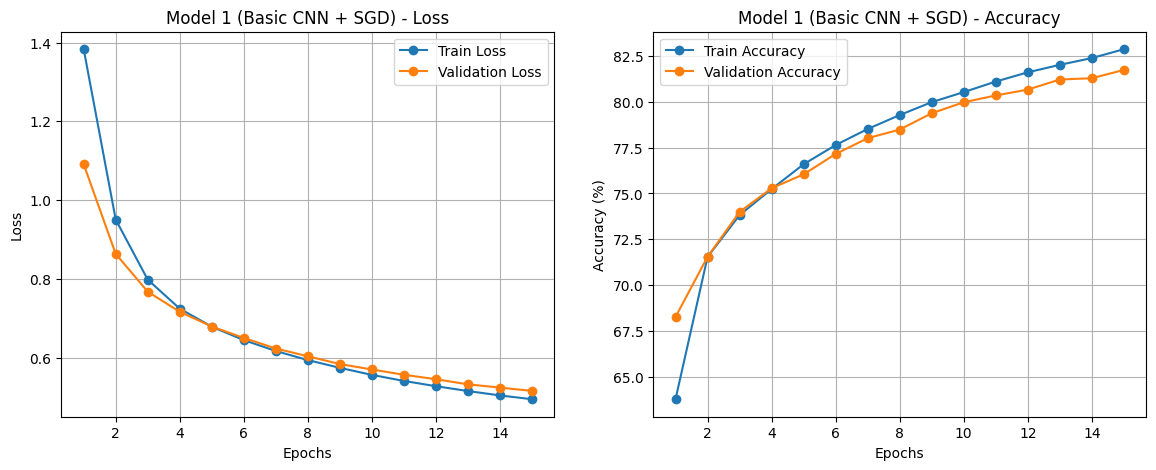

In [16]:
# تحديد عدد الـ Epochs للرسم
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_1, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss_1, label='Validation Loss', marker='o')
plt.title('Model 1 (Basic CNN + SGD) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_1, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_1, label='Validation Accuracy', marker='o')
plt.title('Model 1 (Basic CNN + SGD) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

In [17]:
model_2 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.5), # تحسين 3
    nn.Linear(128, 10)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer_2, step_size=5, gamma=0.5)



In [18]:
epochs = 15
train_loss_2, val_loss_2 = [], []
train_acc_2, val_acc_2 = [], []

for epoch in range(epochs):
    # --- جزء التدريب ---
    model_2.train()
    running_loss = correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_2(images)
        loss = criterion(outputs, labels)

        # التحديث
        optimizer_2.zero_grad(); loss.backward(); optimizer_2.step()

        running_loss += loss.item()
        total += labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss_2.append(running_loss / len(train_loader))
    train_acc_2.append(100 * correct / total)

    scheduler.step()

    # (Validation)
    model_2.eval()
    val_running_loss = val_correct = val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_2(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            val_total += labels.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss_2.append(val_running_loss / len(test_loader))
    val_acc_2.append(100 * val_correct / val_total)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_2[-1]:.4f}, Train Acc: {train_acc_2[-1]:.2f}% | Val Loss: {val_loss_2[-1]:.4f}, Val Acc: {val_acc_2[-1]:.2f}%")

Epoch [1/15] | Train Loss: 1.0638, Train Acc: 60.80% | Val Loss: 0.5051, Val Acc: 81.96%
Epoch [2/15] | Train Loss: 0.6876, Train Acc: 73.90% | Val Loss: 0.4446, Val Acc: 84.25%
Epoch [3/15] | Train Loss: 0.5818, Train Acc: 78.61% | Val Loss: 0.3770, Val Acc: 86.46%
Epoch [4/15] | Train Loss: 0.5129, Train Acc: 81.55% | Val Loss: 0.3549, Val Acc: 87.54%
Epoch [5/15] | Train Loss: 0.4706, Train Acc: 83.06% | Val Loss: 0.3219, Val Acc: 88.50%
Epoch [6/15] | Train Loss: 0.4140, Train Acc: 85.12% | Val Loss: 0.2964, Val Acc: 89.23%
Epoch [7/15] | Train Loss: 0.3939, Train Acc: 86.03% | Val Loss: 0.3030, Val Acc: 89.23%
Epoch [8/15] | Train Loss: 0.3838, Train Acc: 86.39% | Val Loss: 0.2953, Val Acc: 89.39%
Epoch [9/15] | Train Loss: 0.3743, Train Acc: 86.55% | Val Loss: 0.2864, Val Acc: 90.12%
Epoch [10/15] | Train Loss: 0.3632, Train Acc: 87.06% | Val Loss: 0.2819, Val Acc: 90.30%
Epoch [11/15] | Train Loss: 0.3363, Train Acc: 88.14% | Val Loss: 0.2651, Val Acc: 90.75%
Epoch [12/15] | Tra

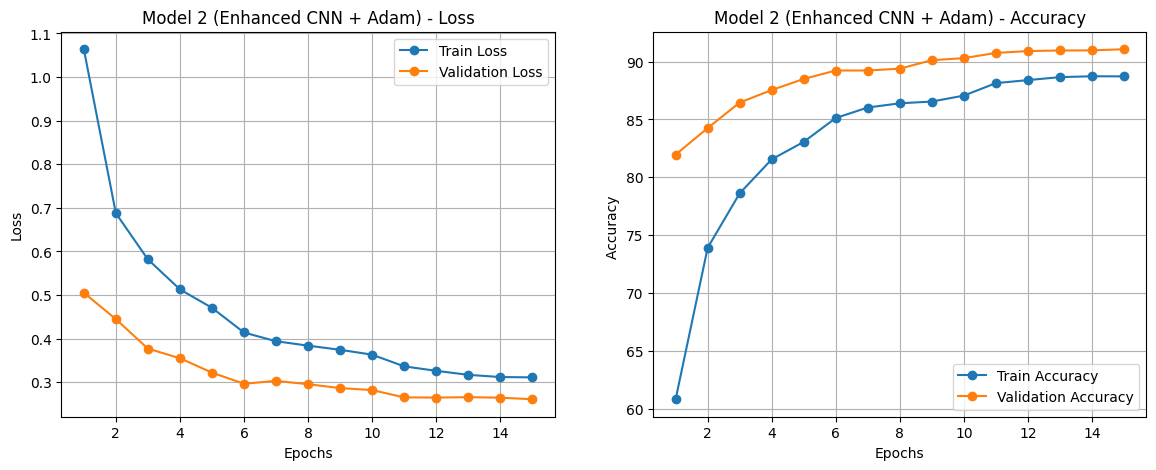

In [19]:

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_2, label='Train Loss', marker='o')
plt.plot(epochs_range, val_loss_2, label='Validation Loss', marker='o')
plt.title('Model 2 (Enhanced CNN + Adam) - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_2, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_2, label='Validation Accuracy', marker='o')
plt.title('Model 2 (Enhanced CNN + Adam) - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy ')
plt.legend();
plt.grid(True)

plt.show()

In [20]:
import pandas as pd

print("\n" + "="*50)
print("             FINAL RESULTS COMPARISON")
print("="*50)

data = {
    "Model Experiment": ["Model 1 (Simple + SGD)", "Model 2 (Enhanced + Adam)"],
    "Final Accuracy (%)": [f"{val_acc_1[-1]:.2f}%", f"{val_acc_2[-1]:.2f}%"],
    "Final Loss": [f"{val_loss_1[-1]:.4f}", f"{val_loss_2[-1]:.4f}"]
}

results_df = pd.DataFrame(data)
print(results_df.to_string(index=False))


             FINAL RESULTS COMPARISON
         Model Experiment Final Accuracy (%) Final Loss
   Model 1 (Simple + SGD)             81.73%     0.5154
Model 2 (Enhanced + Adam)             91.07%     0.2609
